<a href="https://colab.research.google.com/github/tensorbytes0202/Defect_detectionIn_manufacturing_Using_autoencoder/blob/main/Defect_detection(Bottles)using_AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
zip_path = "/content/drive/MyDrive/bottle.zip"
extract_path =  "Bottle_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Complete!")

Extraction Complete!


In [3]:
!pip install torch torchvision matplotlib

In [4]:
import torch
import torch.nn as nn

class AutoEncoder(nn.Module):

    def __init__(self):
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 3,
                kernel_size=2,
                stride=2
            ),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [6]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root="//content/Bottle_dataset/bottle/train",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [15]:
test_dataset = datasets.ImageFolder(
    root="/content/Bottle_dataset/bottle/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = AutoEncoder().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 20

train_losses = [] # Initialize list to store training losses

for epoch in range(epochs):

    running_loss = 0

    for images,_ in train_loader:

        images = images.to(device)

        outputs = model(images)

        loss = criterion(outputs,images)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader) # Calculate average loss for the epoch
    train_losses.append(epoch_loss) # Append to the list

    print(
        f"Epoch {epoch+1}: "
        f"{epoch_loss:.6f}"
    )

Epoch 1: 0.130377
Epoch 2: 0.124221
Epoch 3: 0.107567
Epoch 4: 0.080500
Epoch 5: 0.053160
Epoch 6: 0.033746
Epoch 7: 0.024432
Epoch 8: 0.018699
Epoch 9: 0.015297
Epoch 10: 0.012951
Epoch 11: 0.011168
Epoch 12: 0.009811
Epoch 13: 0.008792
Epoch 14: 0.007916
Epoch 15: 0.007128
Epoch 16: 0.006490
Epoch 17: 0.005913
Epoch 18: 0.005354
Epoch 19: 0.004848
Epoch 20: 0.004426


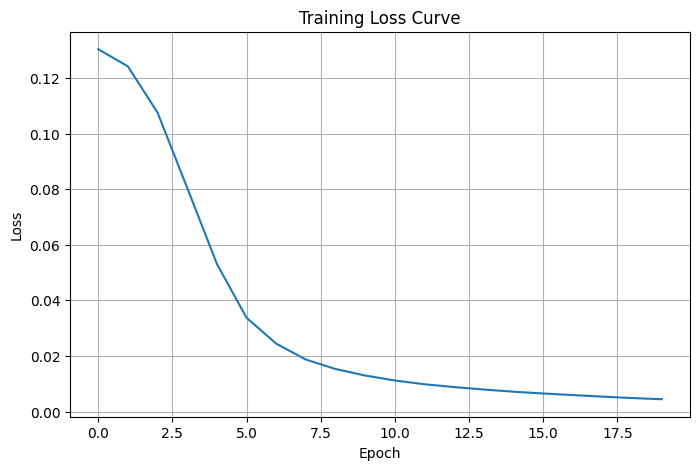

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid()

plt.show()

In [11]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/autoencoder.pth"
)

In [16]:
errors = []
y_true = []
y_pred = []

threshold = 0.01 # Define the threshold for defect detection

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        batch_errors = torch.mean((images - outputs)**2, dim=[1,2,3])
        errors.extend(batch_errors.cpu().numpy())

        for i, error_val in enumerate(batch_errors):
            prediction = 1 if error_val > threshold else 0
            # Assuming label 0 is 'good' and other labels are 'defective'
            actual = 0 if labels[i].item() == 0 else 1
            y_pred.append(prediction)
            y_true.append(actual)

print("Reconstruction errors, true labels, and predicted labels collected for test set.")

Reconstruction errors, true labels, and predicted labels collected for test set.


In [29]:
from PIL import Image

img = Image.open(
"/content/Bottle_dataset/bottle/test/broken_large/016.png"
)

img = transform(img).unsqueeze(0)

img = img.to(device)

model.eval()

with torch.no_grad():

    reconstruction = model(img)

    error = torch.mean(
        (img-reconstruction)**2
    )

print(
    "Reconstruction Error:",
    error.item()
)

Reconstruction Error: 0.004945768974721432


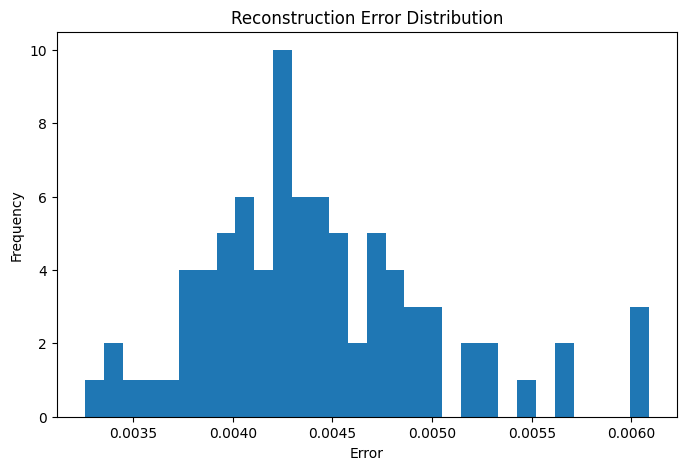

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    errors, # Corrected typo: 'erors' to 'errors'
    bins=30
)

plt.title(
    "Reconstruction Error Distribution"
)

plt.xlabel(
    "Error"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [31]:
threshold = 0.01

if error > threshold:
    print("DEFECT DETECTED")
else:
    print("NORMAL PRODUCT")


NORMAL PRODUCT


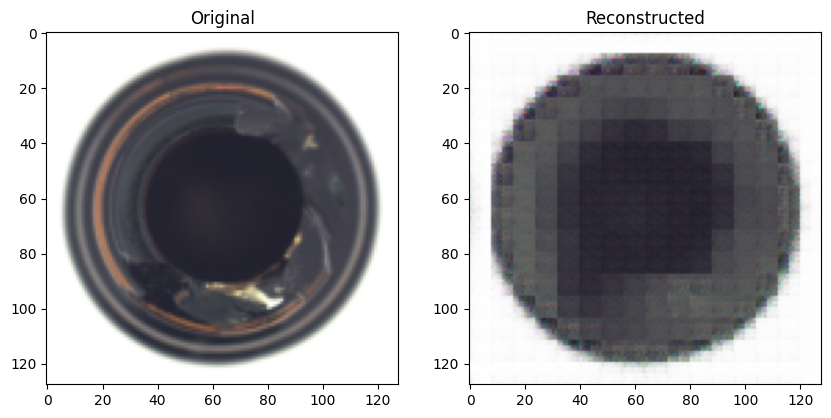

In [32]:
import matplotlib.pyplot as plt

orig = img.squeeze().cpu().permute(1,2,0)

recon = reconstruction.squeeze().cpu().permute(1,2,0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(recon)
plt.title("Reconstructed")

plt.show()

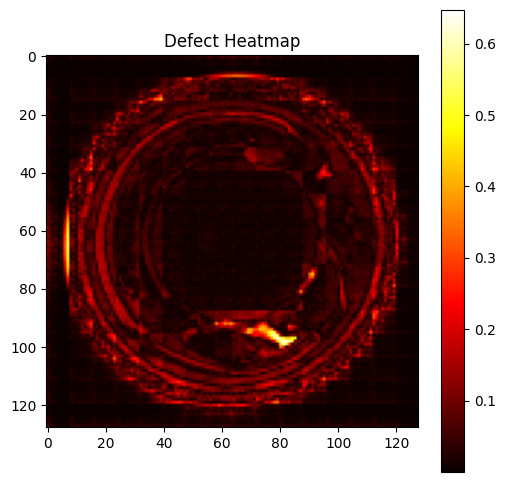

In [33]:
difference = torch.abs(
    img - reconstruction
)

difference = difference.squeeze()

heatmap = difference.mean(0).cpu()

plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap="hot"
)

plt.colorbar()

plt.title("Defect Heatmap")

plt.show()

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [35]:
prediction = 1 if error > threshold else 0

# The 'label' variable is not defined in this scope.
# Assuming this cell is meant to classify the single image processed in cell 'a7pZBWi3joxJ',
# which is '/content/Bottle_dataset/bottle/test/broken_large/003.png'.
# This image is from a 'broken_large' folder, indicating it is a defective product.
# If 'normal' products are represented by 0 and 'defective' by 1,
# then for this specific image, the actual label should be 1.
actual = 1

y_pred.append(prediction)

y_true.append(actual)

In [36]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.23529411764705882
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[20  0]
 [65  0]]


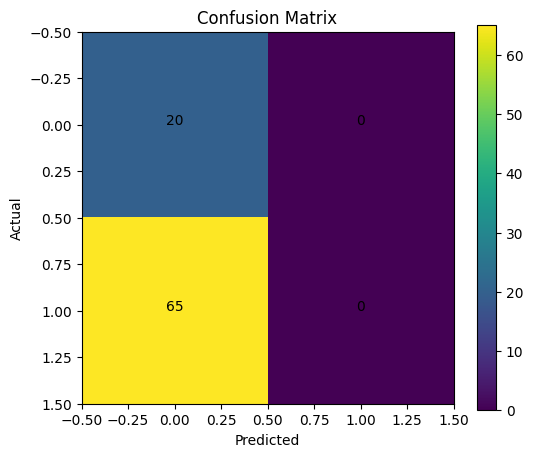

In [38]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i,j],
            ha="center"
        )

plt.show()